# SYTEME DE PREDICTION DU FUTURE METIER D'UN ELEVE EN FONCTION DE SES NOTES

# 1- EXPLORATION DES DONNEES

1.1- Importation des bibliotheques

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, learning_curve 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
import joblib



1.2- Affichage du dataset

In [83]:
df=pd.read_csv("cs_students.csv")
print(df)

     Student ID            Name  Gender  Age  GPA             Major  \
0             1      John Smith    Male   21  3.5  Computer Science   
1             2   Alice Johnson  Female   20  3.2  Computer Science   
2             3    Robert Davis    Male   22  3.8  Computer Science   
3             4    Emily Wilson  Female   21  3.7  Computer Science   
4             5   Michael Brown    Male   23  3.4  Computer Science   
..          ...             ...     ...  ...  ...               ...   
175         176    Elijah Davis    Male   22  3.7  Computer Science   
176         177    Emma Johnson  Female   20  3.6  Computer Science   
177         178     Liam Wilson    Male   21  3.4  Computer Science   
178         179  Sophia Johnson  Female   22  3.5  Computer Science   
179         180   Michael Brown    Male   23  3.7  Computer Science   

           Interested Domain                     Projects  \
0    Artificial Intelligence          Chatbot Development   
1               Data Scie

1.3- affiche le nombre de ligne et de colonne

In [84]:
df.shape

(180, 12)

1.4- Affichage des differentes relations entre les variables numeriques

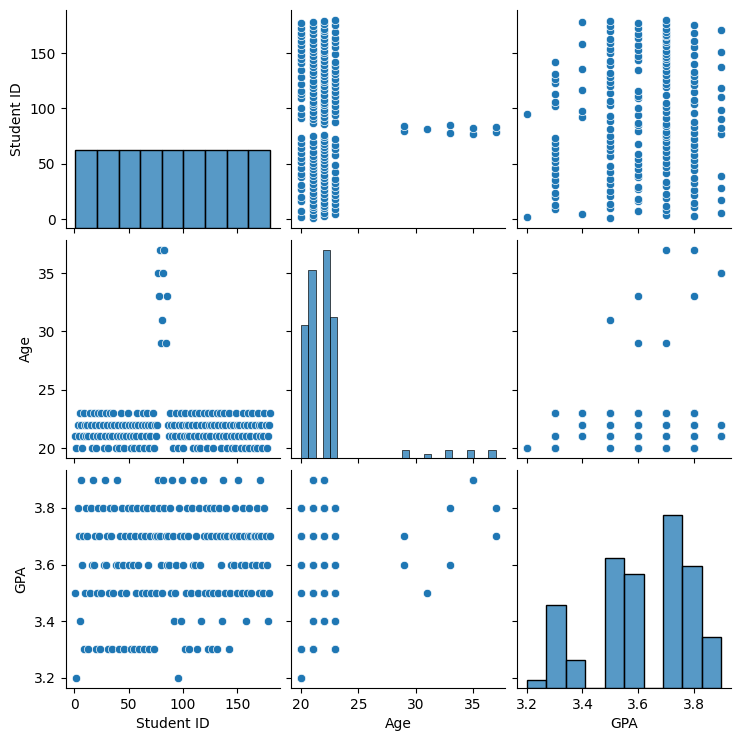

In [85]:
sns.pairplot(df)
plt.show()

1.5- Affiche l'entete du dataset

In [86]:
df.head()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


1.6- Affiche le nombre de Femmes et Hommes qu'il y a dans le domaine de l'informatique

In [87]:
df.groupby("Gender")["Major"].value_counts()

Gender  Major           
Female  Computer Science     78
Male    Computer Science    102
Name: count, dtype: int64

1.7-  Affiche la moyenne en fonction du sexe

In [88]:
df.groupby("Gender")["GPA"].value_counts()

Gender  GPA
Female  3.7    23
        3.5    22
        3.8    10
        3.6     8
        3.9     8
        3.3     5
        3.2     2
Male    3.6    21
        3.7    21
        3.8    21
        3.3    16
        3.5    11
        3.4     7
        3.9     5
Name: count, dtype: int64

1.8- Histogramme des sexes

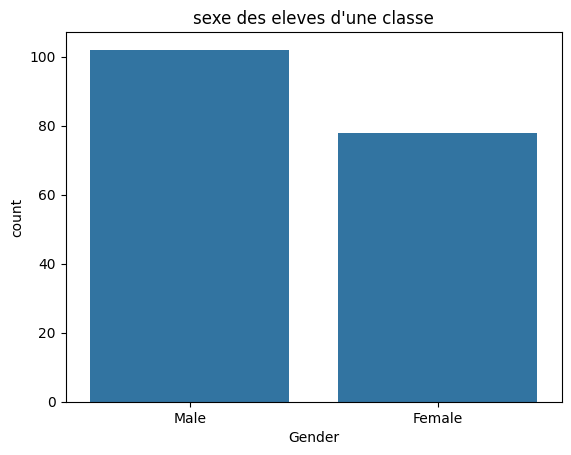

In [89]:
sns.countplot(x="Gender", data=df)
plt.title("sexe des eleves d'une classe")
plt.show()

1.9- Histogramme des Ages

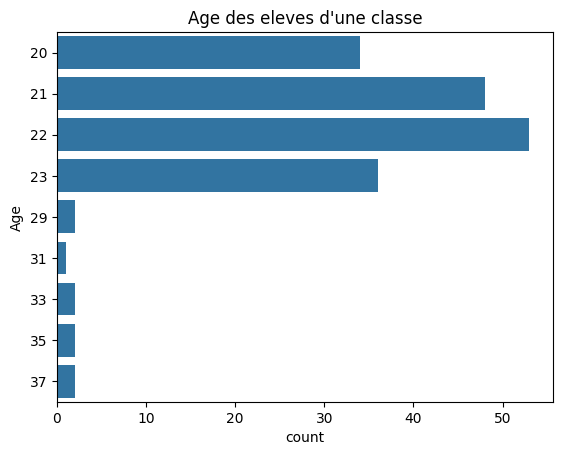

In [90]:
sns.countplot(y="Age",data=df)
plt.title("Age des eleves d'une classe")
plt.show()

1.10- Decrire le dataset

In [91]:
df.describe()

,Student ID,Age,GPA
count,180.000000,180.000000,180.000000
mean,90.500000,22.116667,3.615000
std,52.105662,2.823040,0.177341
min,1.000000,20.000000,3.200000
25%,45.750000,21.000000,3.500000
50%,90.500000,22.000000,3.600000
75%,135.250000,22.250000,3.700000
max,180.000000,37.000000,3.900000


1.11- Courbe de progression des moyennes (GPA)

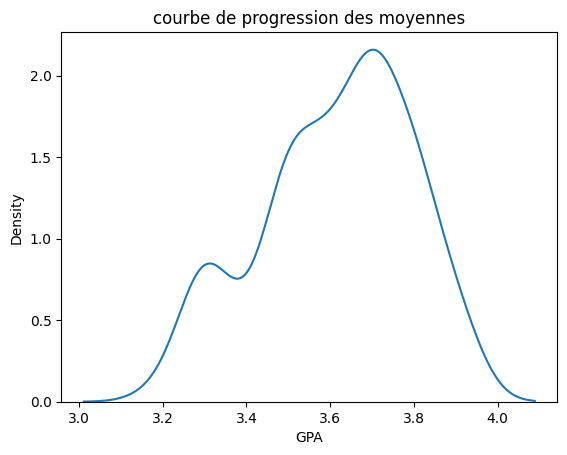

In [92]:
sns.kdeplot(df.GPA)
plt.title("courbe de progression des moyennes")
plt.show()

1.12-Affiche les information des variable

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


1.13- Affiche les colonnes

In [94]:
df.columns

Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')

1.14- affiche le nombre de valuer manquante dans chaque colonne

In [95]:
df.isnull().sum()

Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64

In [96]:

df['moyenne'] = df['GPA'] * 5

# 2- TRAITEMENT DES DONNEES

In [97]:
df

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java,moyenne
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak,17.5
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak,16.0
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average,19.0
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong,18.5
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong,18.5
176,177,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak,18.0
177,178,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak,17.0
178,179,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average,17.5


2.1- Suppression des colonnes unitiles  du dataset

In [98]:
df=df.drop(columns=["Name","Student ID","Major","GPA"],axis=1)
df

,Gender,Age,Interested Domain,Projects,Future Career,Python,SQL,Java,moyenne
0,Male,21,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak,17.5
1,Female,20,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak,16.0
2,Male,22,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average,19.0
3,Female,21,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong,18.5
4,Male,23,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong,17.0
...,...,...,...,...,...,...,...,...,...
175,Male,22,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong,18.5
176,Female,20,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak,18.0
177,Male,21,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak,17.0
178,Female,22,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average,17.5


2.2- Affiche la boite a moustache des moyennes (GPA)

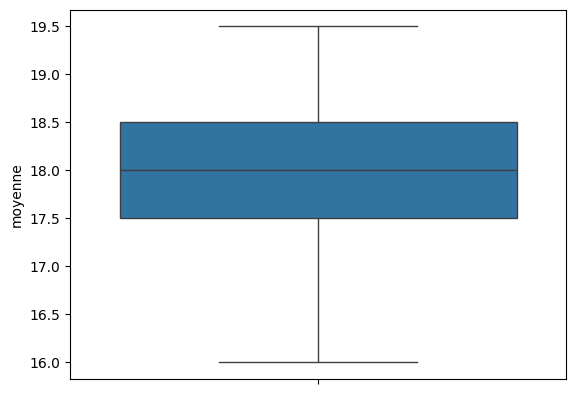

In [99]:
sns.boxplot(data=df,y="moyenne")
plt.show()

2.3- Histogrammme et repartition des future career les plus convoiter

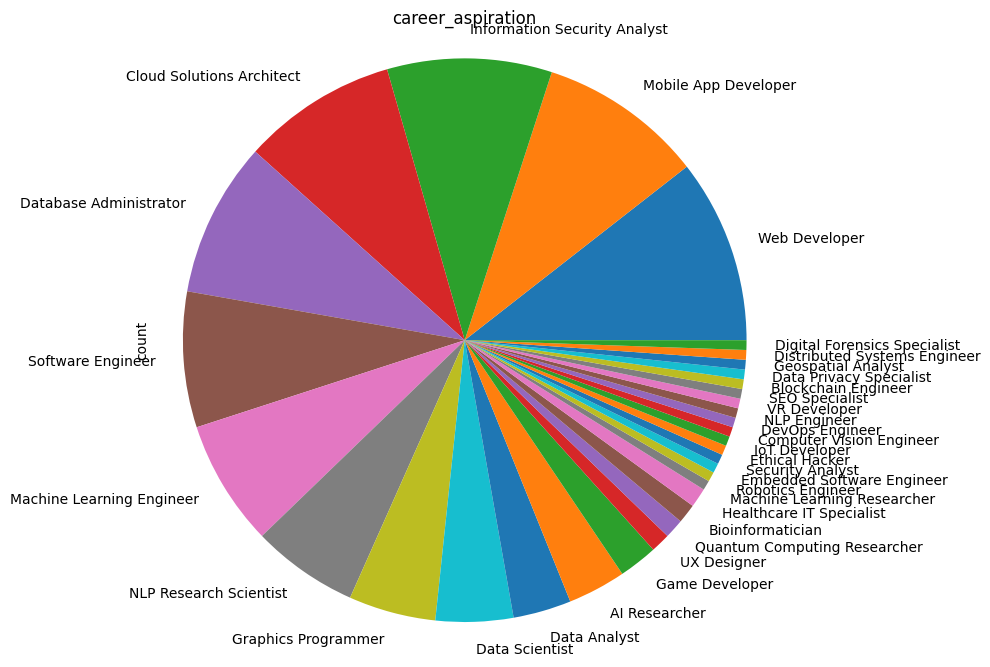

In [100]:
plt.figure(figsize=(8, 8))
df['Future Career'].value_counts().plot(kind='pie')
plt.title('career_aspiration')
plt.axis('equal')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21280\1094452979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df["Future Career"].value_counts().sort_values(ascending=False).index, x=df["Future Career"].value_counts().sort_values(ascending=False).values, palette="viridis")


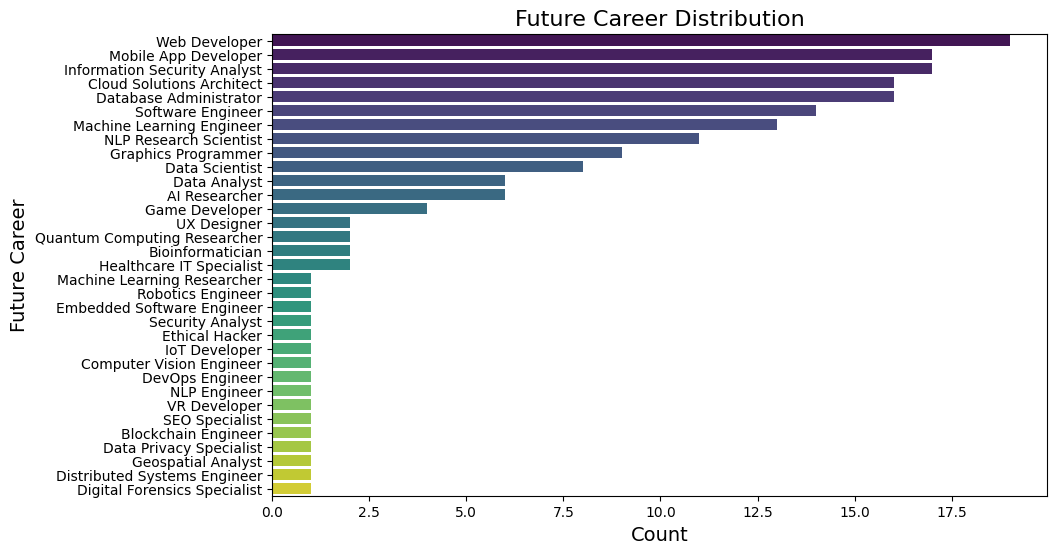

In [101]:
plt.figure(figsize=(10, 6))
sns.barplot(y=df["Future Career"].value_counts().sort_values(ascending=False).index, x=df["Future Career"].value_counts().sort_values(ascending=False).values, palette="viridis")
plt.title("Future Career Distribution", fontsize=16)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Future Career", fontsize=14)
plt.show()

2.4- Histogramme du niveau des eleves dans la maitrise des langages informatiques

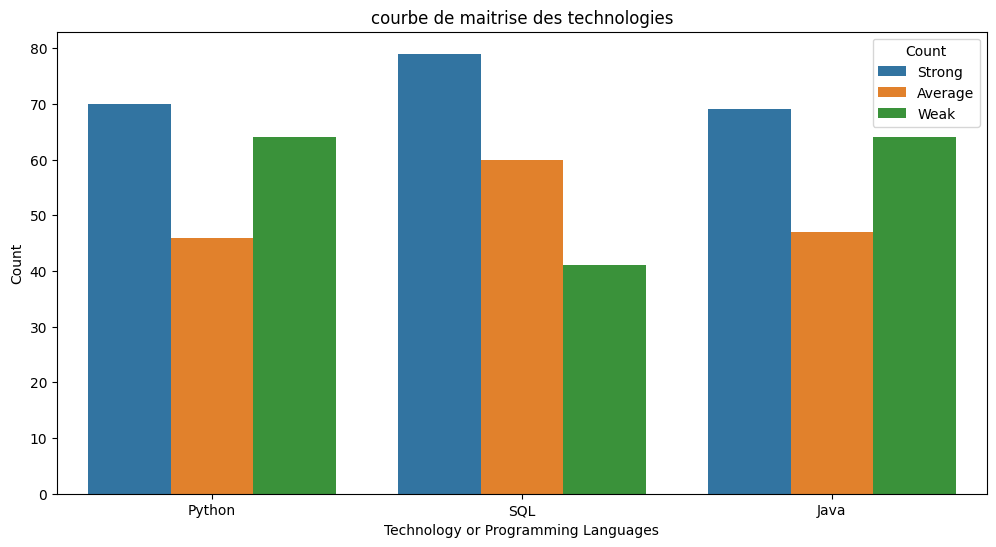

In [102]:
long_df = pd.melt(df, value_vars=["Python", "SQL", "Java"], var_name="Technology", value_name="Count")
plt.figure(figsize=(12,6))
sns.countplot(data=long_df, x=long_df['Technology'],hue="Count")
plt.title('courbe de maitrise des technologies')
plt.ylabel('Count')
plt.xlabel('Technology or Programming Languages')
plt.show()

2.5- Encodage du niveaux de compétence dans les langages de programmation

In [103]:
skill_mapping = {'Weak': 0, 'Average': 1, 'Strong': 2}
df['Python'] = df['Python'].map(skill_mapping)
df['SQL'] = df['SQL'].map(skill_mapping)
df['Java'] = df['Java'].map(skill_mapping)
df


,Gender,Age,Interested Domain,Projects,Future Career,Python,SQL,Java,moyenne
0,Male,21,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,2,2,0,17.5
1,Female,20,Data Science,Data Analytics,Data Scientist,1,2,0,16.0
2,Male,22,Software Development,E-commerce Website,Software Engineer,2,2,1,19.0
3,Female,21,Web Development,Full-Stack Web App,Web Developer,0,2,2,18.5
4,Male,23,Cybersecurity,Network Security,Information Security Analyst,1,0,2,17.0
...,...,...,...,...,...,...,...,...,...
175,Male,22,Web Development,Full-Stack Web App,Web Developer,0,2,2,18.5
176,Female,20,Cybersecurity,Security Auditing,Information Security Analyst,2,1,0,18.0
177,Male,21,Machine Learning,Natural Language Processing,Machine Learning Engineer,2,1,0,17.0
178,Female,22,Database Management,SQL Database Administration,Database Administrator,0,2,1,17.5


2.6-  Encoder les colonnes catégorielles

In [104]:
label = ['Gender', 'Interested Domain', 'Projects', 'Future Career']
encoders = {}
for col in label:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # pour décoder plus tard si besoin

df

,Gender,Age,Interested Domain,Projects,Future Career,Python,SQL,Java,moyenne
0,1,21,0,8,21,2,2,0,17.5
1,0,20,10,15,7,1,2,0,16.0
2,1,22,24,21,29,2,2,1,19.0
3,0,21,26,26,32,0,2,2,18.5
4,1,23,7,40,18,1,0,2,17.0
...,...,...,...,...,...,...,...,...,...
175,1,22,26,26,32,0,2,2,18.5
176,0,20,7,53,18,2,1,0,18.0
177,1,21,19,39,20,2,1,0,17.0
178,0,22,11,49,8,0,2,1,17.5


In [105]:
decoded_future_career = encoders['Future Career'].inverse_transform(df['Future Career'])
print(decoded_future_career) 

['Machine Learning Researcher' 'Data Scientist' 'Software Engineer'
 'Web Developer' 'Information Security Analyst'
 'Machine Learning Engineer' 'Database Administrator'
 'Cloud Solutions Architect' 'Mobile App Developer' 'Graphics Programmer'
 'NLP Research Scientist' 'Web Developer' 'Mobile App Developer'
 'Game Developer' 'Software Engineer' 'Information Security Analyst'
 'Machine Learning Engineer' 'Database Administrator'
 'Cloud Solutions Architect' 'Mobile App Developer' 'Graphics Programmer'
 'NLP Research Scientist' 'Web Developer' 'Mobile App Developer'
 'Game Developer' 'Software Engineer' 'Information Security Analyst'
 'Machine Learning Engineer' 'Database Administrator'
 'Cloud Solutions Architect' 'Mobile App Developer' 'Graphics Programmer'
 'NLP Research Scientist' 'Web Developer' 'Mobile App Developer'
 'Game Developer' 'Software Engineer' 'Information Security Analyst'
 'Machine Learning Engineer' 'Cloud Solutions Architect'
 'Software Engineer' 'Web Developer' 'Mob

2.7- Matrice de correlation

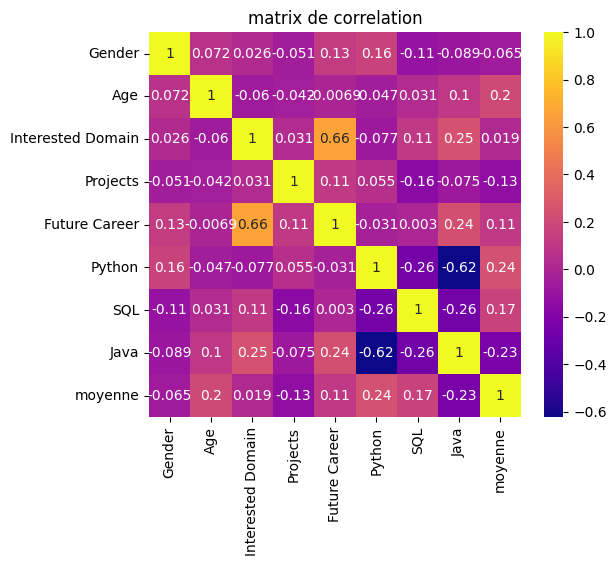

In [106]:
matrix = df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot = True, cmap = "plasma")
plt.title("matrix de correlation")
plt.show()

 D'apres ma matrice de correlation les valuers qui influence notre cible sont:
- Gender
- GPA
- interested Domain
- Projects
- Future career
- java

2.8- suppresion des colonnes unitiles

In [107]:
df=df.drop(columns=["Age","SQL",'Gender'],axis=1)

# 3- ENTRAINNEMENT DU MODELE

3.1- Affichage du dataset final

In [108]:
df

,Interested Domain,Projects,Future Career,Python,Java,moyenne
0,0,8,21,2,0,17.5
1,10,15,7,1,0,16.0
2,24,21,29,2,1,19.0
3,26,26,32,0,2,18.5
4,7,40,18,1,2,17.0
...,...,...,...,...,...,...
175,26,26,32,0,2,18.5
176,7,53,18,2,0,18.0
177,19,39,20,2,0,17.0
178,11,49,8,0,1,17.5


3.2- Declaration des variables

In [109]:
X=df.drop('Future Career' , axis=1)
y=df['Future Career']

In [110]:
df_bal = pd.concat([X, y], axis=1)

In [111]:
# Étape 2 : Trouver la classe majoritaire
max_count = df_bal['Future Career'].value_counts().max()

In [112]:
# Étape 3 : Sur-échantillonner chaque classe
df_resampled = pd.DataFrame()
for label in df_bal['Future Career'].unique():
    df_label = df_bal[df_bal['Future Career'] == label]
    df_label_resampled = resample(df_label,
                                   replace=True,
                                   n_samples=max_count,
                                   random_state=42)
    df_resampled = pd.concat([df_resampled, df_label_resampled])

In [113]:
# Étape 4 : Réobtenir X et y équilibrés
X_balanced = df_resampled[X.columns]
y_balanced = df_resampled['Future Career']

In [114]:
# Étape 5 : Split train/test
X_train, X_test, y_train, y_test = train_test_split( X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42)

In [130]:
# Vérifier distribution des classes
print("Distribution des classes :")
print(y_balanced.value_counts())

Distribution des classes :
Future Career
21    19
7     19
29    19
32    19
18    19
20    19
8     19
3     19
22    19
16    19
24    19
14    19
28    19
12    19
5     19
26    19
13    19
4     19
9     19
1     19
19    19
23    19
30    19
17    19
25    19
31    19
2     19
27    19
6     19
15    19
11    19
10    19
0     19
Name: count, dtype: int64


In [131]:
# Vérifier NaN
print("Valeurs manquantes :", y.isnull().sum())

# Supprimer ou imputer les NaN
y = y_balanced.dropna()
df = df.loc[y_balanced.index]  # Supprimer les lignes correspondantes dans X


Valeurs manquantes : 0


In [132]:
# Taille du test
test_size = 0.2  # 20%

# Vérifier que chaque classe a assez d’exemples
min_samples_per_class = y_balanced.value_counts().min()
if min_samples_per_class < 2:
    print("⚠️ Certaines classes ont moins de 2 exemples, stratify pourrait échouer !")
    test_size = 0.1  # réduire test_size pour éviter l’erreur


In [115]:
# 4️⃣ Standardisation
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [116]:
# 3. Modèle KNN (non optimisé)
# ==============================
knn = KNeighborsClassifier()  # paramètres par défaut
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [117]:
# Prédictions
y_pred = knn.predict(X_test)


In [118]:
# Accuracy
print("🔹 Accuracy (KNN non optimisé):", accuracy_score(y_test, y_pred))

🔹 Accuracy (KNN non optimisé): 0.9761904761904762


In [119]:

# ✅ Rapport complet : précision, rappel, f1-score
print("🔹 Rapport de classification (Precision, Recall, F1-score):\n")
print(classification_report(y_test, y_pred))



🔹 Rapport de classification (Precision, Recall, F1-score):

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       0.75      1.00      0.86         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         4
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         3
          16       1.

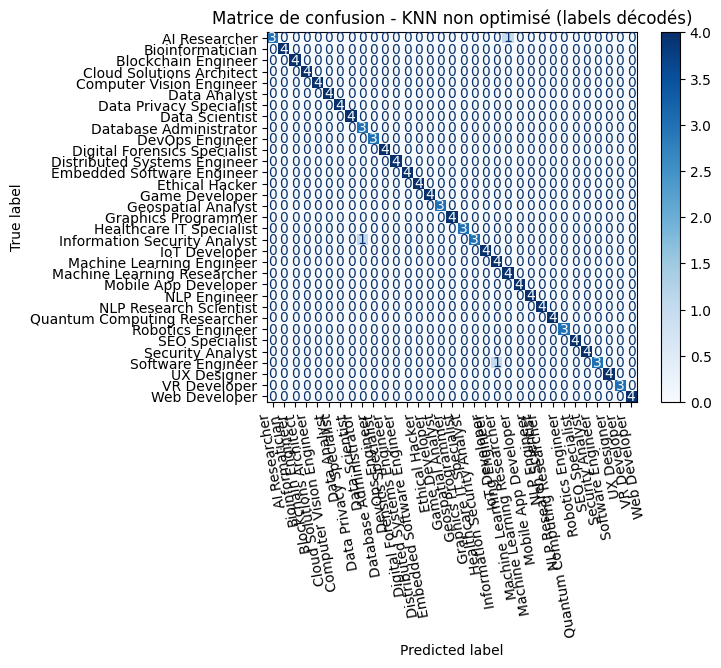

In [120]:
# Décodage des labels pour la matrice
y_test_labels = encoders['Future Career'].inverse_transform(y_test)
y_pred_labels = encoders['Future Career'].inverse_transform(y_pred)

# Matrice de confusion décodée
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=encoders['Future Career'].classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=encoders['Future Career'].classes_)
disp.plot(cmap="Blues", xticks_rotation=100)
plt.title("Matrice de confusion - KNN non optimisé (labels décodés)")
plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\s

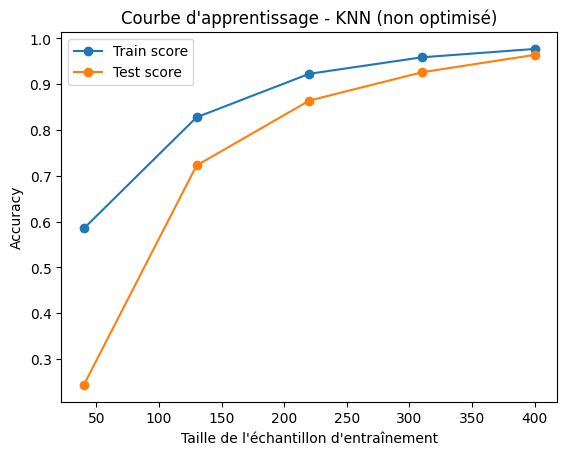

In [129]:
# ✅ Courbe d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    knn, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Train score")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Test score")
plt.title("Courbe d'apprentissage - KNN (non optimisé)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# DEPLOIEMENT

In [122]:
# Sauvegarde dans un fichier .pkl
joblib.dump(knn, 'modele.pkl')

['modele.pkl']

In [123]:
joblib.dump(X.columns.tolist(), 'colonnes_info.pkl')

['colonnes_info.pkl']

In [124]:
from sklearn.preprocessing import LabelEncoder
joblib.dump(encoders, 'label_TI.pkl')

['label_TI.pkl']

In [125]:
# 7️⃣ Enregistrement des objets pour Streamlit
# =========================

joblib.dump(scaler, "scaler_TI.pkl")

joblib.dump({'model_columns': X.columns.tolist(), 'Interested Domain': [col for col in X.columns if 'Interested Domain' in col]}, "model_columns_TI.pkl")

print("✅ Tous les objets pour Streamlit ont été enregistrés !")

✅ Tous les objets pour Streamlit ont été enregistrés !
